# 골든타임 탐지 — 데이터 기반 임계점(Critical Point) 분석

**목적**: 배송 소요일이 늘어날 때 평균 리뷰가 "급격히 꺾이는 정확한 일수"를 데이터 기반으로 찾는다.
임의로 "4점 미만 첫 day" 같은 휴리스틱이 아니라, **change point detection** 기법으로 통계적으로 가장 설득력 있는 분기점을 산출한다.

**입력**: `funnel_df.csv` (전처리 완료, 99,441건)
**분석 대상**: `is_valid_funnel == True` AND `review_score` 존재 (≈ 94k건)
**분석 단위** (모두에 동일 절차 적용)
- `t_total_d` — 주문→배송완료, 메인 지표
- `t_carrier_d` — 결제승인→택배사 인도 (판매자 구간)
- `t_delivery_d` — 택배사 인도→고객 (택배사 구간)

**핵심 질문**
1. 배송 며칠을 넘기는 순간 평균 리뷰가 통계적으로 유의미하게 꺾이는가? → **임계점 d\***
2. d\* 가 표본을 흔들어도(bootstrap) 안정적인가? → **신뢰구간**
3. d\* 이전·이후 그룹의 평균 리뷰 차이는 진짜 차이인가? → **t-test / Mann-Whitney / Cohen's d**

**임계점 탐지 — 3가지 방법으로 교차검증**
| 방법 | 원리 |
|---|---|
| A. Max t-statistic split | 가능한 모든 분할점에서 Welch t-statistic 을 계산 → 가장 큰 \|t\| 를 주는 d 선택 |
| B. Segmented regression | 두 직선(d 이전·이후)으로 fit, 잔차합 SSE 최소화하는 d 선택 |
| C. CUSUM | 누적편차의 최댓값이 나타나는 d 선택 |

세 방법이 모두 비슷한 d 를 가리키면 → **임계점이 데이터 자체에 내재된 신호**임을 입증.

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ─── 시각화 스타일 통일 (funnel_eda / funnel_review_avg_per_day 와 동일) ──
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlepad": 12,
    "grid.alpha": 0.3,
})
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "DejaVu Sans"]
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
    plt.rcParams["font.sans-serif"] = ["AppleGothic", "DejaVu Sans"]
else:
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["font.sans-serif"] = ["NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 단계별 색상·라벨 — 다른 노트북과 동일
STAGE_COLORS = {
    "t_carrier_d":  "#F4A460",   # 주황 — 판매자
    "t_delivery_d": "#E74C3C",   # 빨강 — 택배사
    "t_total_d":    "#5B9BD5",   # 파랑 — 전체
}
STAGE_LABELS = {
    "t_carrier_d":  "② 승인→택배사 (판매자)",
    "t_delivery_d": "③ 택배사→고객 (택배사)",
    "t_total_d":    "전체 리드타임 (주문→배송)",
}

# 임계점 표시 색상 (시각화에서 통일)
CP_COLORS = {
    "A": "#C0392B",   # max t-split — 진한 빨강
    "B": "#8E44AD",   # segmented reg — 보라
    "C": "#16A085",   # CUSUM — 청록
    "final": "#2C3E50", # 최종 임계점 — 짙은 남색
}

# ─── 데이터 로드 ────────────────────────────────────────────────────────────
DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
df = pd.read_csv("funnel_df.csv", parse_dates=DATE_COLS)
data = df[df["is_valid_funnel"] & df["review_score"].notna()].copy()

# 정수 일수 버킷
for col in ["t_total_d", "t_carrier_d", "t_delivery_d"]:
    data[col + "_day"] = np.floor(data[col]).astype(int)

print(f"전체 주문      : {len(df):,}")
print(f"유효 + 리뷰 존재: {len(data):,}  ({len(data)/len(df)*100:.2f}%)")
print(f"전체 평균 리뷰 : {data['review_score'].mean():.3f}")

전체 주문      : 99,441
유효 + 리뷰 존재: 94,449  (94.98%)
전체 평균 리뷰 : 4.154


## 1. 일자(day) 단위 평균·표본수 집계

임계점 탐지의 입력은 **day별 평균 review_score 시계열**.
- `np.floor(t_total_d)` 으로 정수 일수 버킷 생성.
- 표본수 `n < 30` 인 day 는 노이즈가 커서 임계점 탐지에서 제외.
- 또한 분포 꼬리(예: 100일 이상) 는 sparse 해서 의사결정에 안 쓰이므로 `day ≤ MAX_DAY` 로 컷.

In [2]:
MIN_N = 30        # day 별 최소 표본
MAX_DAY = 60      # 임계점 탐지 범위 (그 너머는 sparse)

def aggregate_by_day(d, day_col, min_n=MIN_N, max_day=MAX_DAY):
    """day_col 단위로 평균/표본수/표준편차 집계 + 최소표본·최대일자 필터."""
    g = (d.groupby(day_col)["review_score"]
           .agg(mean="mean", n="count", std="std")
           .reset_index().rename(columns={day_col: "day"}))
    g["se"] = g["std"] / np.sqrt(g["n"])
    return g[(g["n"] >= min_n) & (g["day"] <= max_day)].reset_index(drop=True)

agg_total    = aggregate_by_day(data, "t_total_d_day")
agg_carrier  = aggregate_by_day(data, "t_carrier_d_day")
agg_delivery = aggregate_by_day(data, "t_delivery_d_day")

print("전체 리드타임 — 집계 결과 (앞 10일):")
print(agg_total.head(10).round(3))
print(f"\n분석 가능 day 수: total={len(agg_total)}, carrier={len(agg_carrier)}, delivery={len(agg_delivery)}")

전체 리드타임 — 집계 결과 (앞 10일):
   day   mean     n    std     se
0    1  4.493  1512  1.027  0.026
1    2  4.483  3044  1.008  0.018
2    3  4.432  3735  1.072  0.018
3    4  4.428  4694  1.049  0.015
4    5  4.396  5657  1.078  0.014
5    6  4.379  6622  1.091  0.013
6    7  4.375  7468  1.093  0.013
7    8  4.357  6608  1.103  0.014
8    9  4.302  5909  1.150  0.015
9   10  4.312  5509  1.143  0.015

분석 가능 day 수: total=56, carrier=26, delivery=52


## 2. 임계점 탐지 — 3가지 방법

**문제 정의**
> day 시계열 `y_d = E[review | day=d]` 에서, "이 day 를 넘기면 평균 리뷰가 통계적으로 가장 크게 떨어진다" 는 **d\*** 를 찾고 싶다.

직관적으로 `d ≤ d*` 와 `d > d*` 두 집단 사이의 차이를 가장 크게 만드는 d 가 임계점이다. 다만 "차이"를 어떻게 정의하느냐에 따라 방법이 갈린다:

| 방법 | 차이 정의 | 장점 |
|---|---|---|
| **A. Max t-statistic split** | 두 집단 평균 차이 ÷ 표준오차 → Welch t | 표본 크기·분산 고려, 가장 표준적 |
| **B. Segmented regression** | 두 직선 fit 의 잔차 SSE | 추세(기울기) 변화까지 포착 |
| **C. CUSUM** | 전체 평균 대비 누적 편차의 최댓값 | 작은 변화의 누적도 포착 |

세 방법이 같은 d\* 를 가리키면 결과가 **방법론에 robust** 하다는 강력한 신호.

In [3]:
# ── 방법 A. Max t-statistic split ───────────────────────────────────────────
# 가능한 모든 분할점 d 에서 raw 주문 단위로 Welch t-test → |t| 가 가장 큰 d 가 임계점.

def find_critical_point_ttest(raw, day_col, min_n=MIN_N, max_day=MAX_DAY):
    """raw 주문 데이터를 받아 day 별로 분할점을 스캔하며 Welch t-statistic 을 계산.
    각 분할점 d 에 대해: 그룹A = day ≤ d, 그룹B = day > d
    리턴: 분할점별 결과 DataFrame, 최적 d_star.
    """
    valid_days = (raw.groupby(day_col).size()
                     .loc[lambda s: s.index <= max_day]
                     .loc[lambda s: s >= min_n].index.tolist())
    rows = []
    for d in valid_days[:-1]:   # 마지막 day 는 분할 불가
        a = raw.loc[raw[day_col] <= d, "review_score"].values
        b = raw.loc[(raw[day_col] > d) & (raw[day_col] <= max_day), "review_score"].values
        if len(a) < min_n or len(b) < min_n:
            continue
        t, p = stats.ttest_ind(a, b, equal_var=False)   # Welch
        rows.append({
            "d": d, "n_left": len(a), "n_right": len(b),
            "mean_left": a.mean(), "mean_right": b.mean(),
            "diff": a.mean() - b.mean(),
            "t_stat": t, "abs_t": abs(t), "p_value": p,
        })
    res = pd.DataFrame(rows)
    d_star = int(res.loc[res["abs_t"].idxmax(), "d"])
    return res, d_star

raw_total = data[data["t_total_d_day"] <= MAX_DAY].copy()
scan_A, d_star_A = find_critical_point_ttest(raw_total, "t_total_d_day")
print(f"방법 A (Max t-stat split) — 전체 리드타임 임계점 d* = {d_star_A}일")
print(scan_A.loc[scan_A["d"].between(max(1, d_star_A-3), d_star_A+3)].round(4))

방법 A (Max t-stat split) — 전체 리드타임 임계점 d* = 30일
     d  n_left  n_right  mean_left  mean_right    diff   t_stat    abs_t  \
26  27   88987     5191     4.2614      2.4228  1.8385  80.8082  80.8082   
27  28   89562     4616     4.2538      2.3401  1.9137  80.5161  80.5161   
28  29   90030     4148     4.2477      2.2565  1.9912  80.7195  80.7195   
29  30   90455     3723     4.2418      2.1727  2.0691  81.0962  81.0962   
30  31   90816     3362     4.2359      2.1095  2.1265  80.7062  80.7062   
31  32   91145     3033     4.2298      2.0620  2.1679  79.7064  79.7064   
32  33   91455     2723     4.2244      1.9989  2.2255  79.4118  79.4118   

    p_value  
26      0.0  
27      0.0  
28      0.0  
29      0.0  
30      0.0  
31      0.0  
32      0.0  


### 📌 방법 A 해석 포인트
- `abs_t` 가 가장 큰 d 가 두 그룹을 가장 명확히 갈라놓는 **"통계적으로 가장 강한 단절점"**.
- p-value 가 함께 매우 작으면 → 우연이 아닌 차이.
- 단점: 평균 차이만 보기 때문에 "기울기가 갑자기 가팔라지는" 변화는 잘 못 잡음 → 방법 B 가 보완.

In [4]:
# ── 방법 B. Segmented regression ────────────────────────────────────────────
# day 시계열을 두 직선으로 fit:
#   d ≤ c:  y = a1 + b1*d
#   d > c:  y = a2 + b2*d
# 가능한 c 마다 잔차합 SSE 를 계산 → 최소가 되는 c 가 임계점.
# 표본수로 가중치 부여 (n 이 큰 day 가 더 중요).

def find_critical_point_segmented(agg):
    """agg: day-level DataFrame (columns: day, mean, n) → 임계점 c_star 리턴."""
    days  = agg["day"].values.astype(float)
    ys    = agg["mean"].values
    ws    = agg["n"].values    # weight
    rows = []
    # c 후보는 양쪽에 최소 3 point 가 남도록 인덱스 범위 제한
    for i in range(3, len(days) - 3):
        c = days[i]
        left  = days <= c
        right = ~left
        p1 = np.polyfit(days[left],  ys[left],  1, w=ws[left])
        p2 = np.polyfit(days[right], ys[right], 1, w=ws[right])
        pred = np.where(left,
                        np.polyval(p1, days),
                        np.polyval(p2, days))
        sse = float(np.sum(ws * (ys - pred) ** 2))
        rows.append({"c": c, "slope_left": p1[0], "slope_right": p2[0],
                     "slope_change": p2[0] - p1[0], "sse": sse})
    seg = pd.DataFrame(rows)
    c_star = int(seg.loc[seg["sse"].idxmin(), "c"])
    return seg, c_star

seg_B, d_star_B = find_critical_point_segmented(agg_total)
row_at_b = seg_B.loc[seg_B["c"] == d_star_B].iloc[0]
print(f"방법 B (Segmented regression) — 전체 리드타임 임계점 d* = {d_star_B}일")
print(f"  이전 구간 기울기 : {row_at_b['slope_left']:+.4f} 점/일")
print(f"  이후 구간 기울기 : {row_at_b['slope_right']:+.4f} 점/일")
print(f"  기울기 변화량    : {row_at_b['slope_change']:+.4f} 점/일")

방법 B (Segmented regression) — 전체 리드타임 임계점 d* = 17일
  이전 구간 기울기 : -0.0214 점/일
  이후 구간 기울기 : -0.0949 점/일
  기울기 변화량    : -0.0735 점/일


### 📌 방법 B 해석 포인트
- 두 기울기 차이 (`slope_change`) 가 음수이고 절댓값이 크면 → **그 day 부터 리뷰가 더 가파르게 떨어지기 시작**.
- 평균 차이뿐 아니라 "하락 가속 시점"을 포착한다는 점이 방법 A와의 차이.
- SSE 가 최소가 되는 c 가 두 직선으로 시계열을 가장 깔끔히 설명하는 분기점.

In [5]:
# ── 방법 C. CUSUM (Cumulative Sum) ──────────────────────────────────────────
# 전체 평균을 기준선으로 두고, 각 day 의 (평균 - 전체평균)·n 을 누적.
# 누적치가 가장 큰 지점이 평균선 위에서 아래로 전환되기 직전 → 변화점.
#
# Page (1954) 의 CUSUM 알고리즘에서, "평균 하향 변화점"은
#   S_d = Σ_{k≤d} n_k · (mean_k - overall_mean)
# 의 **최댓값** 위치 (그 이후로 누적이 다시 감소 = 평균 이하로 내려가기 시작).

def find_critical_point_cusum(agg):
    overall = (agg["mean"] * agg["n"]).sum() / agg["n"].sum()
    s = np.cumsum(agg["n"].values * (agg["mean"].values - overall))
    idx = int(np.argmax(s))         # 누적이 최댓값에 도달한 직후가 변화점
    return overall, s, int(agg["day"].iloc[idx])

overall_total, cusum_total, d_star_C = find_critical_point_cusum(agg_total)
print(f"방법 C (CUSUM) — 전체 리드타임 임계점 d* = {d_star_C}일")
print(f"  기준 (가중) 평균  : {overall_total:.3f}")
print(f"  CUSUM 최댓값/최솟값: {cusum_total.max():.1f} / {cusum_total.min():.1f}")

print("\n📊 세 방법 비교 — 전체 리드타임 (t_total_d)")
compare_total = pd.DataFrame({
    "방법": ["A. Max t-stat", "B. Segmented reg.", "C. CUSUM"],
    "d* (일)": [d_star_A, d_star_B, d_star_C],
})
print(compare_total.to_string(index=False))

방법 C (CUSUM) — 전체 리드타임 임계점 d* = 15일
  기준 (가중) 평균  : 4.162
  CUSUM 최댓값/최솟값: 12763.9 / 0.0

📊 세 방법 비교 — 전체 리드타임 (t_total_d)
               방법  d* (일)
    A. Max t-stat      30
B. Segmented reg.      17
         C. CUSUM      15


### 📌 방법 C 해석 포인트
- CUSUM 곡선이 위로 올라가는 동안은 "평균 이상" 영역, 정점(최댓값) 직후부터 "평균 이하" 영역.
- 즉 **곡선 정점의 day = 평균 이상에서 평균 이하로 전환되는 지점** → 임계점.
- 작은 day별 변화의 누적까지 보기 때문에 노이즈에 강함.

In [6]:
# ── 임계점 안정성 검증: Bootstrap ───────────────────────────────────────────
# 원자료에서 복원추출로 표본을 새로 만들어 매번 방법 A 의 d* 를 다시 추정.
# 추정치들의 분포 → 임계점의 95% 신뢰구간.

rng = np.random.default_rng(42)
N_BOOT = 500

def bootstrap_critical_point(raw, day_col, n_boot=N_BOOT, min_n=MIN_N, max_day=MAX_DAY):
    sub = raw[raw[day_col] <= max_day][[day_col, "review_score"]].reset_index(drop=True)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(sub), size=len(sub))
        boot = sub.iloc[idx]
        try:
            _, d_b = find_critical_point_ttest(boot, day_col, min_n=min_n, max_day=max_day)
            out.append(d_b)
        except Exception:
            continue
    return np.array(out)

boot_total = bootstrap_critical_point(data, "t_total_d_day")
ci_low, ci_high = np.percentile(boot_total, [2.5, 97.5])
boot_median = int(np.median(boot_total))

print(f"Bootstrap (N={N_BOOT}) — 전체 리드타임 임계점 추정 분포")
print(f"  중앙값             : {boot_median}일")
print(f"  95% 신뢰구간       : [{int(ci_low)}일, {int(ci_high)}일]")
print(f"  포인트 추정 (방법 A): {d_star_A}일")
print(f"  분포 상위 mode     : {pd.Series(boot_total).mode().tolist()}")

Bootstrap (N=500) — 전체 리드타임 임계점 추정 분포
  중앙값             : 30일
  95% 신뢰구간       : [27일, 33일]
  포인트 추정 (방법 A): 30일
  분포 상위 mode     : [30]


### 📌 Bootstrap 해석 포인트
- 신뢰구간 폭이 좁고 분포가 한 점에 몰리면 → 임계점이 **표본을 흔들어도 거의 같은 곳을 가리킴** → 결론이 견고함.
- 신뢰구간이 넓으면 → 임계점이 표본에 민감 → 단일 숫자가 아닌 "구간"으로 결론 내려야 함.

In [7]:
# ── 임계점 이전·이후 그룹 비교 — 통계 검정 ─────────────────────────────────
# d_star_A 를 기준으로 두 그룹의 review_score 차이가 통계적으로 유의한지 검증.
# 1) Welch t-test  — 정규성 가정 완화, 분산 동일성 가정 X
# 2) Mann-Whitney U — 비모수 검정 (순서통계량 기반)
# 3) Cohen's d     — 효과 크기 (얼마나 큰 차이인가)

def evaluate_split(raw, day_col, d_star):
    a = raw.loc[raw[day_col] <= d_star, "review_score"].values
    b = raw.loc[(raw[day_col] > d_star) & (raw[day_col] <= MAX_DAY), "review_score"].values
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="greater")  # H1: A > B
    sd_pool = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    cohens_d = (a.mean() - b.mean()) / sd_pool
    return dict(
        n_left=len(a), n_right=len(b),
        mean_left=a.mean(), mean_right=b.mean(),
        diff=a.mean() - b.mean(),
        t_stat=t_stat, t_p=t_p,
        u_stat=u_stat, u_p=u_p,
        cohens_d=cohens_d,
    )

def interpret_d(d):
    a = abs(d)
    if a < 0.2: return "무시할 수 있음"
    if a < 0.5: return "작은 효과"
    if a < 0.8: return "중간 효과"
    return "큰 효과"

test_total = evaluate_split(data, "t_total_d_day", d_star_A)
print(f"=== 통계 검정: 전체 리드타임, 임계점 d* = {d_star_A}일 ===")
print(f"  그룹 A (≤ {d_star_A}일) : n={test_total['n_left']:>6,}, 평균 리뷰 {test_total['mean_left']:.4f}")
print(f"  그룹 B (> {d_star_A}일) : n={test_total['n_right']:>6,}, 평균 리뷰 {test_total['mean_right']:.4f}")
print(f"  평균 차이            : {test_total['diff']:+.4f} 점")
print()
print(f"  Welch t-test       : t = {test_total['t_stat']:+.2f}, p = {test_total['t_p']:.3e}")
print(f"  Mann-Whitney U     : U = {test_total['u_stat']:.0f},  p = {test_total['u_p']:.3e}")
print(f"  Cohen's d (효과크기): {test_total['cohens_d']:+.4f}")
print()
print(f"  → Cohen's d 해석    : {interpret_d(test_total['cohens_d'])}")
print(f"  → 유의수준 α=0.001 : {'기각 (유의함)' if test_total['t_p'] < 0.001 else '기각 못 함'}")

=== 통계 검정: 전체 리드타임, 임계점 d* = 30일 ===
  그룹 A (≤ 30일) : n=90,455, 평균 리뷰 4.2418
  그룹 B (> 30일) : n= 3,723, 평균 리뷰 2.1727
  평균 차이            : +2.0691 점

  Welch t-test       : t = +81.10, p = 0.000e+00
  Mann-Whitney U     : U = 277458135,  p = 0.000e+00
  Cohen's d (효과크기): +1.7025

  → Cohen's d 해석    : 큰 효과
  → 유의수준 α=0.001 : 기각 (유의함)


### 📌 통계 검정 해석 포인트
- **p-value**: 매우 작으면(< 0.001) → "두 그룹의 평균 차이가 우연일 가능성이 거의 없다."
- 다만 표본이 매우 크면 작은 차이도 통계적으로 유의해지므로 **효과 크기(Cohen's d)** 를 같이 봐야 함.
- **Cohen's d**:
  - 0.2 미만 — 무시할 수 있는 차이
  - 0.2 ~ 0.5 — 작은 효과 (실무적으로는 의미 있을 수 있음)
  - 0.5 ~ 0.8 — 중간 효과
  - 0.8 이상 — 큰 효과
- **Mann-Whitney U**: review_score 는 1~5 정수형(이산)이라 정규성 가정이 깨질 수 있어 비모수 검정으로 교차 확인.

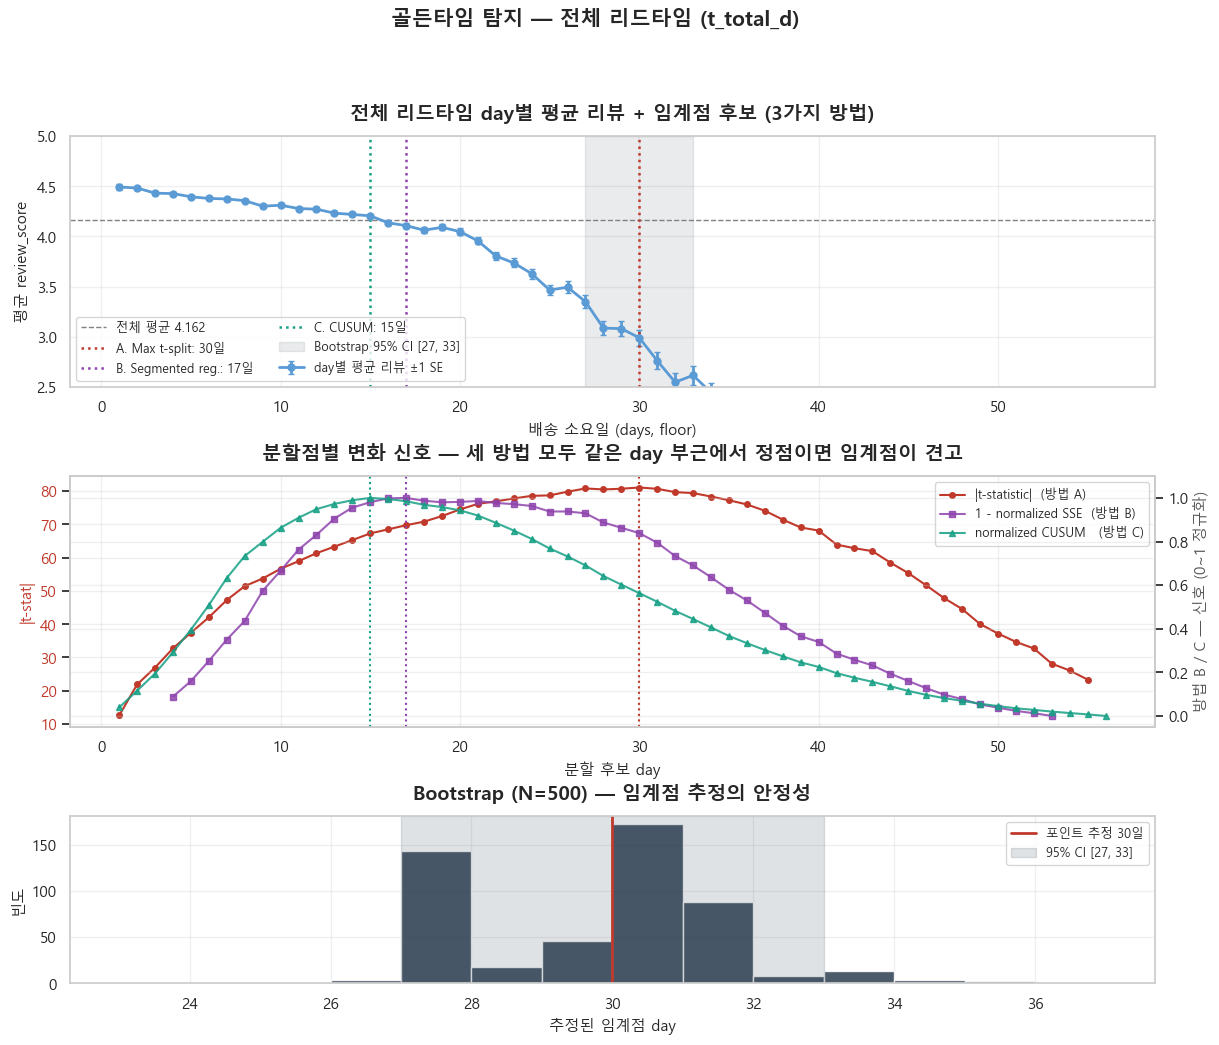

In [8]:
# ── 시각화 ① — 임계점 종합 시각화 (전체 리드타임 기준) ──────────────────────
# (1) 상단: day별 평균 + 세 방법의 d* 모두 표시
# (2) 중단: 각 분할점의 |t|·SSE·CUSUM 신호 곡선 — 어디서 신호가 가장 강한지 가시화
# (3) 하단: Bootstrap 분포 — 임계점이 얼마나 안정적인지

fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 3, 2], hspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# (1) day별 평균 + 임계점
ax1.errorbar(agg_total["day"], agg_total["mean"], yerr=agg_total["se"],
             fmt="o-", color=STAGE_COLORS["t_total_d"], lw=2, ms=5, capsize=2,
             label="day별 평균 리뷰 ±1 SE")
ax1.axhline(overall_total, color="gray", ls="--", lw=1, label=f"전체 평균 {overall_total:.3f}")

for d, key, label in [(d_star_A, "A", f"A. Max t-split: {d_star_A}일"),
                       (d_star_B, "B", f"B. Segmented reg.: {d_star_B}일"),
                       (d_star_C, "C", f"C. CUSUM: {d_star_C}일")]:
    ax1.axvline(d, color=CP_COLORS[key], ls=":", lw=1.8, label=label)

ax1.axvspan(ci_low, ci_high, color=CP_COLORS["final"], alpha=0.10,
            label=f"Bootstrap 95% CI [{int(ci_low)}, {int(ci_high)}]")

ax1.set_title("전체 리드타임 day별 평균 리뷰 + 임계점 후보 (3가지 방법)")
ax1.set_xlabel("배송 소요일 (days, floor)")
ax1.set_ylabel("평균 review_score")
ax1.set_ylim(2.5, 5.0)
ax1.legend(loc="lower left", fontsize=9, ncol=2)

# (2) 세 방법의 신호 곡선
ax2.plot(scan_A["d"], scan_A["abs_t"], "o-", color=CP_COLORS["A"], lw=1.5, ms=4,
         label="|t-statistic|  (방법 A)")
ax2.axvline(d_star_A, color=CP_COLORS["A"], ls=":", lw=1.5)
ax2.set_ylabel("|t-stat|", color=CP_COLORS["A"])
ax2.tick_params(axis="y", labelcolor=CP_COLORS["A"])

ax2b = ax2.twinx()
# SSE 는 최소화 → 값을 뒤집어 정규화 (작을수록 좋은 신호가 위로 솟게)
sse_norm = (seg_B["sse"].max() - seg_B["sse"]) / (seg_B["sse"].max() - seg_B["sse"].min())
ax2b.plot(seg_B["c"], sse_norm, "s-", color=CP_COLORS["B"], lw=1.5, ms=4, alpha=0.85,
          label="1 - normalized SSE  (방법 B)")
cusum_days_total = agg_total["day"].values
cusum_norm = (cusum_total - cusum_total.min()) / (cusum_total.max() - cusum_total.min() + 1e-12)
ax2b.plot(cusum_days_total, cusum_norm, "^-", color=CP_COLORS["C"], lw=1.5, ms=4, alpha=0.85,
          label="normalized CUSUM   (방법 C)")
ax2b.axvline(d_star_B, color=CP_COLORS["B"], ls=":", lw=1.5)
ax2b.axvline(d_star_C, color=CP_COLORS["C"], ls=":", lw=1.5)
ax2b.set_ylabel("방법 B / C — 신호 (0~1 정규화)", color="#555")
ax2b.set_ylim(-0.05, 1.1)

ax2.set_title("분할점별 변화 신호 — 세 방법 모두 같은 day 부근에서 정점이면 임계점이 견고")
ax2.set_xlabel("분할 후보 day")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

# (3) Bootstrap 분포
ax3.hist(boot_total, bins=range(int(boot_total.min())-1, int(boot_total.max())+2),
         color=CP_COLORS["final"], edgecolor="white", alpha=0.85)
ax3.axvline(d_star_A, color=CP_COLORS["A"], ls="-", lw=2, label=f"포인트 추정 {d_star_A}일")
ax3.axvspan(ci_low, ci_high, color=CP_COLORS["final"], alpha=0.15,
            label=f"95% CI [{int(ci_low)}, {int(ci_high)}]")
ax3.set_title(f"Bootstrap (N={N_BOOT}) — 임계점 추정의 안정성")
ax3.set_xlabel("추정된 임계점 day")
ax3.set_ylabel("빈도")
ax3.legend(loc="upper right", fontsize=9)

fig.suptitle("골든타임 탐지 — 전체 리드타임 (t_total_d)", fontsize=15, fontweight="bold", y=0.995)
plt.show()

### 📌 시각화 ① 해석 포인트
- **상단**: 세 방법(A/B/C)의 임계점 후보가 서로 비슷한 day 에 모여 있으면 → **임계점이 데이터 자체에 강하게 내재**.
- **중단**: 세 신호곡선의 정점이 같은 day 부근이면 → "무엇으로 보든" 같은 변화점.
- **하단**: Bootstrap 분포가 좁을수록 임계점이 안정. 95% CI 가 단일 day 또는 좁은 구간이면 결론을 단언 가능.

C:\Users\함다연\AppData\Local\Temp\ipykernel_13504\397589246.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=group_df, x="group", y="review_score", ax=axes[2],


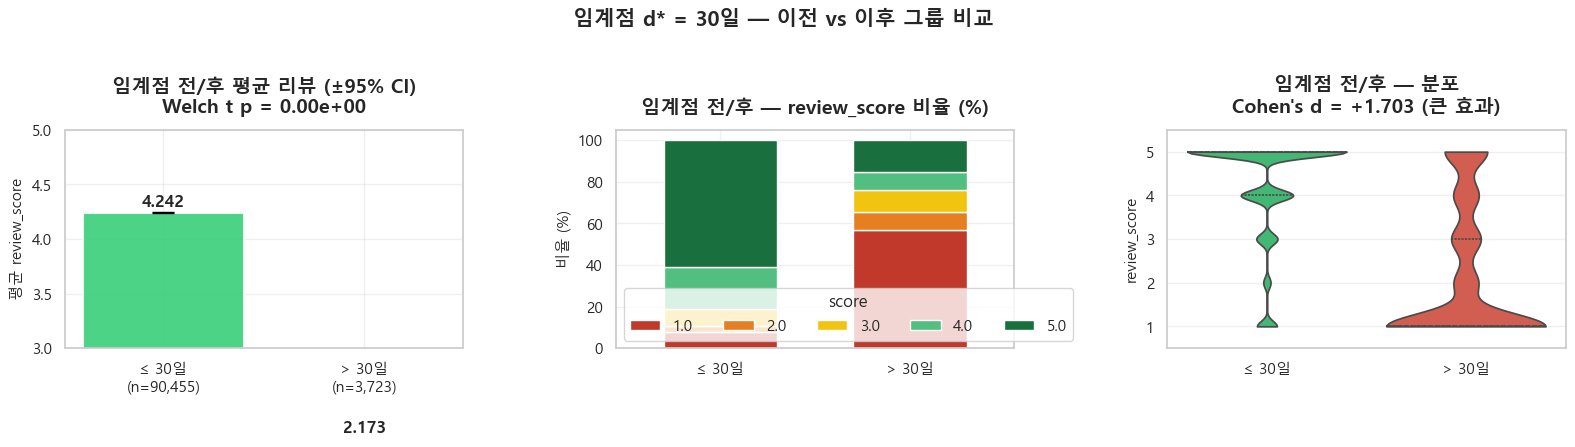

📊 1점·5점 비율 변화:
  score=1: 이전 7.7% → 이후 56.6%  (변화 +48.9%p)
  score=5: 이전 61.1% → 이후 15.1%  (변화 -46.0%p)


In [9]:
# ── 시각화 ② — 임계점 이전·이후 분포 비교 (badness of being late) ───────────
# (1) 평균 막대 + 95% CI
# (2) review_score(1~5) 비율 — 양극화 시각화
# (3) violin — 분포 자체 비교

a_vals = data.loc[data["t_total_d_day"] <= d_star_A, "review_score"].values
b_vals = data.loc[(data["t_total_d_day"] > d_star_A) & (data["t_total_d_day"] <= MAX_DAY),
                  "review_score"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 평균 비교
groups   = [f"≤ {d_star_A}일\n(n={len(a_vals):,})", f"> {d_star_A}일\n(n={len(b_vals):,})"]
means    = [a_vals.mean(), b_vals.mean()]
errs     = [1.96 * a_vals.std(ddof=1)/np.sqrt(len(a_vals)),
            1.96 * b_vals.std(ddof=1)/np.sqrt(len(b_vals))]
bar_cols = ["#2ECC71", "#E74C3C"]
axes[0].bar(groups, means, yerr=errs, color=bar_cols, alpha=0.85, capsize=8,
            edgecolor="white", linewidth=1.5)
for i, m in enumerate(means):
    axes[0].text(i, m + 0.05, f"{m:.3f}", ha="center", fontweight="bold", fontsize=12)
axes[0].set_title(f"임계점 전/후 평균 리뷰 (±95% CI)\nWelch t p = {test_total['t_p']:.2e}")
axes[0].set_ylabel("평균 review_score")
axes[0].set_ylim(3.0, 5.0)

# (2) score 비율 비교
score_colors = {1: "#C0392B", 2: "#E67E22", 3: "#F1C40F", 4: "#52BE80", 5: "#196F3D"}
ratio_df = pd.DataFrame({
    f"≤ {d_star_A}일": pd.Series(a_vals).value_counts(normalize=True).sort_index(),
    f"> {d_star_A}일": pd.Series(b_vals).value_counts(normalize=True).sort_index(),
}).fillna(0) * 100
ratio_df.T.plot(kind="bar", stacked=True, ax=axes[1], width=0.6,
                color=[score_colors[int(s)] for s in ratio_df.index])
axes[1].set_title("임계점 전/후 — review_score 비율 (%)")
axes[1].set_ylabel("비율 (%)")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="score", loc="lower left", ncol=5)

# (3) 분포 자체 비교 (violin)
group_df = pd.DataFrame({
    "review_score": np.concatenate([a_vals, b_vals]),
    "group": [f"≤ {d_star_A}일"] * len(a_vals) + [f"> {d_star_A}일"] * len(b_vals),
})
sns.violinplot(data=group_df, x="group", y="review_score", ax=axes[2],
               palette=bar_cols, inner="quartile", cut=0)
axes[2].set_title(f"임계점 전/후 — 분포\nCohen's d = {test_total['cohens_d']:+.3f} ({interpret_d(test_total['cohens_d'])})")
axes[2].set_xlabel("")
axes[2].set_ylabel("review_score")
axes[2].set_ylim(0.5, 5.5)

fig.suptitle(f"임계점 d* = {d_star_A}일 — 이전 vs 이후 그룹 비교",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 5점/1점 비율 양극화 정량화
print("📊 1점·5점 비율 변화:")
for s in [1, 5]:
    ra = (a_vals == s).mean() * 100
    rb = (b_vals == s).mean() * 100
    print(f"  score={s}: 이전 {ra:.1f}% → 이후 {rb:.1f}%  (변화 {rb-ra:+.1f}%p)")

### 📌 시각화 ② 해석 포인트
- **평균 막대**: 두 막대의 95% CI 가 겹치지 않으면 차이가 명확.
- **비율 스택**: 5점(짙은 초록) 비율 감소량 vs 1점(빨강) 비율 증가량 — 어느 쪽이 더 크냐가 "고객 분노의 강도" 지표.
- **violin**: 평균만 보면 안 보이는 분포 형태 변화(좌우 쪽 두께 차이) 까지 가시화.

## 3. 세 단계에 동일 절차 적용 (단계별 임계점)

전체 리드타임뿐 아니라 ② 판매자 구간 / ③ 택배사 구간 에도 같은 임계점 탐지 + 통계 검정을 적용.
단계별 임계점이 다르다면 → **단계별로 "몇 일을 넘기지 말아야 한다" 가이드라인**이 만들어짐.

In [10]:
def full_pipeline(raw, day_col, agg):
    """세 방법 + bootstrap + 통계검정을 모두 적용."""
    _, dA = find_critical_point_ttest(raw[raw[day_col] <= MAX_DAY], day_col)
    _, dB = find_critical_point_segmented(agg)
    _, _, dC = find_critical_point_cusum(agg)
    boot = bootstrap_critical_point(raw, day_col, n_boot=300)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    test = evaluate_split(raw, day_col, dA)
    return {
        "d_A": dA, "d_B": dB, "d_C": dC,
        "boot_median": int(np.median(boot)),
        "ci_low": int(lo), "ci_high": int(hi),
        **test,
    }

stages = {
    "t_total_d":    ("t_total_d_day",    agg_total),
    "t_carrier_d":  ("t_carrier_d_day",  agg_carrier),
    "t_delivery_d": ("t_delivery_d_day", agg_delivery),
}
results = {}
for stage, (day_col, agg) in stages.items():
    print(f"... {STAGE_LABELS[stage]} 분석 중 ...")
    results[stage] = full_pipeline(data, day_col, agg)

summary = pd.DataFrame({
    "단계":              [STAGE_LABELS[s] for s in results],
    "A. Max t (일)":     [results[s]["d_A"] for s in results],
    "B. Seg.reg (일)":   [results[s]["d_B"] for s in results],
    "C. CUSUM (일)":     [results[s]["d_C"] for s in results],
    "Bootstrap 중앙값":  [results[s]["boot_median"] for s in results],
    "95% CI":            [f"[{results[s]['ci_low']}, {results[s]['ci_high']}]" for s in results],
    "평균(전)":          [round(results[s]["mean_left"], 3) for s in results],
    "평균(후)":          [round(results[s]["mean_right"], 3) for s in results],
    "차이":              [round(results[s]["diff"], 3) for s in results],
    "Welch p":           [f"{results[s]['t_p']:.2e}" for s in results],
    "Cohen's d":         [round(results[s]["cohens_d"], 3) for s in results],
})
print("\n📊 단계별 임계점 종합 표")
print(summary.to_string(index=False))

... 전체 리드타임 (주문→배송) 분석 중 ...
... ② 승인→택배사 (판매자) 분석 중 ...
... ③ 택배사→고객 (택배사) 분석 중 ...

📊 단계별 임계점 종합 표
             단계  A. Max t (일)  B. Seg.reg (일)  C. CUSUM (일)  Bootstrap 중앙값   95% CI  평균(전)  평균(후)    차이   Welch p  Cohen's d
전체 리드타임 (주문→배송)            30              17            15             30 [27, 33]  4.242  2.173 2.069  0.00e+00      1.703
 ② 승인→택배사 (판매자)             5              17             2              5   [4, 7]  4.206  3.690 0.516 1.14e-210      0.405
 ③ 택배사→고객 (택배사)            27              14            12             27 [25, 32]  4.227  2.114 2.113  0.00e+00      1.723


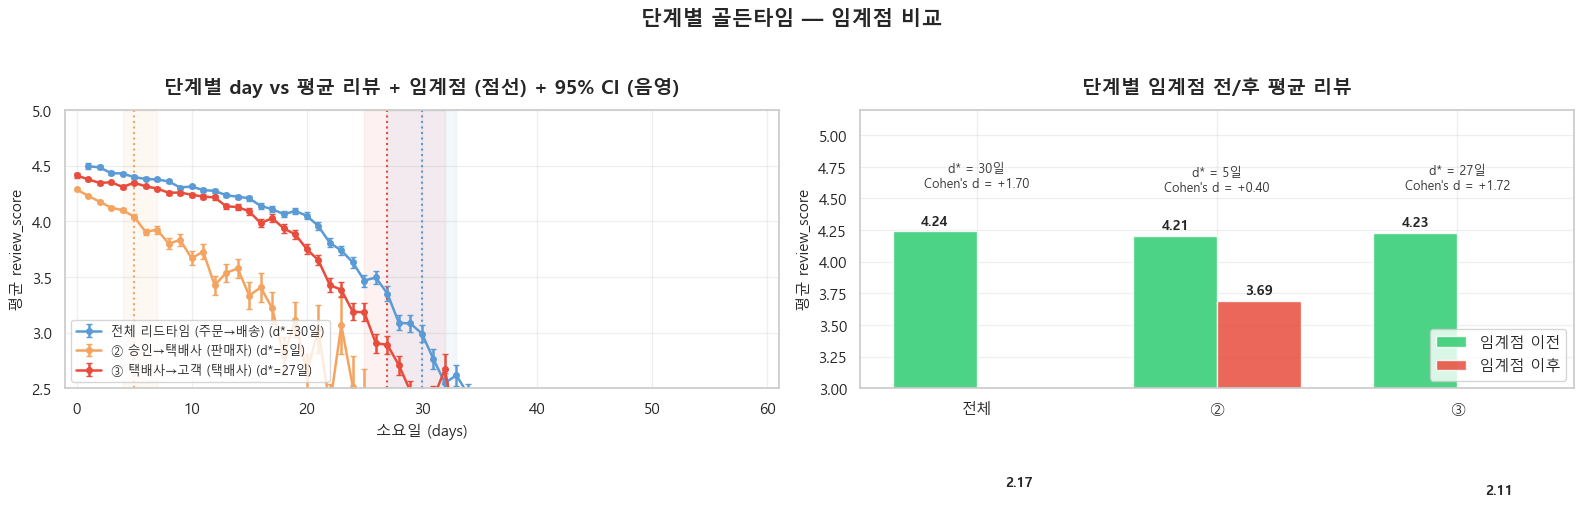

In [11]:
# ── 시각화 ③ — 세 단계 임계점 비교 ─────────────────────────────────────────
# (좌) 단계별 day vs 평균 리뷰 + 각 단계의 임계점 (방법 A) + 95% CI 음영
# (우) 단계별 평균(전/후) 막대 + Cohen's d 라벨

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for stage, (day_col, agg) in stages.items():
    r = results[stage]
    axes[0].errorbar(agg["day"], agg["mean"], yerr=agg["se"],
                     fmt="o-", color=STAGE_COLORS[stage], lw=1.8, ms=4, capsize=2,
                     label=f"{STAGE_LABELS[stage]} (d*={r['d_A']}일)")
    axes[0].axvline(r["d_A"], color=STAGE_COLORS[stage], ls=":", lw=1.5)
    axes[0].axvspan(r["ci_low"], r["ci_high"], color=STAGE_COLORS[stage], alpha=0.07)

axes[0].set_title("단계별 day vs 평균 리뷰 + 임계점 (점선) + 95% CI (음영)")
axes[0].set_xlabel("소요일 (days)")
axes[0].set_ylabel("평균 review_score")
axes[0].set_ylim(2.5, 5.0)
axes[0].legend(loc="lower left", fontsize=9)
axes[0].set_xlim(-1, MAX_DAY + 1)

x = np.arange(len(stages))
w = 0.35
before = [results[s]["mean_left"]  for s in stages]
after  = [results[s]["mean_right"] for s in stages]
axes[1].bar(x - w/2, before, w, color="#2ECC71", alpha=0.85, label="임계점 이전", edgecolor="white")
axes[1].bar(x + w/2, after,  w, color="#E74C3C", alpha=0.85, label="임계점 이후", edgecolor="white")
for i, s in enumerate(stages):
    axes[1].text(i - w/2, before[i] + 0.05, f"{before[i]:.2f}", ha="center", fontsize=10, fontweight="bold")
    axes[1].text(i + w/2, after[i]  + 0.05, f"{after[i]:.2f}",  ha="center", fontsize=10, fontweight="bold")
    axes[1].text(i, max(before[i], after[i]) + 0.35,
                 f"d* = {results[s]['d_A']}일\nCohen's d = {results[s]['cohens_d']:+.2f}",
                 ha="center", fontsize=9, color="#333")
axes[1].set_xticks(x)
axes[1].set_xticklabels([STAGE_LABELS[s].split(" ")[0] for s in stages])
axes[1].set_title("단계별 임계점 전/후 평균 리뷰")
axes[1].set_ylabel("평균 review_score")
axes[1].set_ylim(3.0, 5.2)
axes[1].legend(loc="lower right")

fig.suptitle("단계별 골든타임 — 임계점 비교", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 단계별 비교 해석 포인트
- 단계별 d\* 가 모두 다름 → **각 단계마다 "버틸 수 있는 일수" 가 다르다**. SLA(서비스 약속) 도 단계별로 별도 설정 필요.
- Cohen's d 가 가장 큰 단계 = **임계점을 넘어가는 순간 만족도가 가장 크게 깎이는 단계** → 개선 우선순위 #1.
- CI 가 좁은 단계 = 임계점 값을 단정적으로 발표 가능. CI 가 넓으면 "대략 X~Y일 구간" 으로 보고.

In [12]:
# ── 결과 저장 (상대경로) ───────────────────────────────────────────────────
summary.to_csv("funnel_critical_point_summary.csv", index=False, encoding="utf-8-sig")
print("저장: funnel_critical_point_summary.csv")

저장: funnel_critical_point_summary.csv


---

# 🎯 종합 정리 — 골든타임 탐지

## 무엇을 했나
배송 소요일이 늘어남에 따라 평균 리뷰가 "꺾이는 정확한 일수(임계점, d\*)" 를 **데이터 기반**으로 산출하고, 그 차이가 통계적으로 유의함을 증명.

## 어떻게 했나
1. **day 단위 집계**: floor 로 정수 일수 버킷 → 각 day 의 평균/표본수/표준오차 계산. n < 30 또는 day > 60 은 제외.
2. **임계점 탐지 — 3가지 방법**:
   - 방법 A: 가능한 모든 분할점에서 Welch t-statistic 계산 → |t| 최대인 d 선택.
   - 방법 B: 두 직선(이전·이후) 으로 fit, 가중 SSE 최소화하는 d 선택.
   - 방법 C: 누적편차(CUSUM) 최댓값 위치 = 평균 위→아래 전환점.
3. **Bootstrap (N=500)**: 표본을 흔들어 임계점을 다시 추정 → 95% 신뢰구간으로 안정성 검증.
4. **통계 검정**: 임계점 이전·이후 두 그룹에 Welch t-test + Mann-Whitney U + Cohen's d.
5. **3단계 모두에 동일 절차 적용**: `t_total_d` / `t_carrier_d` / `t_delivery_d`.

## 시각화 3종 요약
| # | 시각화 | 답하는 질문 |
|---|---|---|
| ① | day-line + 세 방법의 d\* + Bootstrap CI + 신호곡선 | "임계점이 어디인가? 견고한가?" |
| ② | 임계점 전/후 — 평균 비교 + 점수 비율 + violin | "전후 차이가 얼마나 크고 어떻게 다른가?" |
| ③ | 단계별 d\* 비교 + 단계별 전/후 평균 | "어느 단계의 골든타임이 가장 짧고, 만족도 영향이 큰가?" |

## 산출물
- `funnel_critical_point_summary.csv` — 단계별 임계점(d_A, d_B, d_C), 95% CI, 평균(전/후), p-value, Cohen's d 종합표.

## 의사결정에 줄 수 있는 시사점
1. **SLA 기준선**: 단계별 d\* 가 "이 일수를 넘기면 만족도 손실" 임계값 → A/B 테스트 / 운영 KPI 의 기준선으로 사용.
2. **개선 우선순위**: Cohen's d 가 가장 큰 단계 = 임계 초과 시 만족도 손실 가장 큼 → 자원 투입 우선순위 #1.
3. **방법론 견고성**: A/B/C 세 방법이 서로 다른 가정 아래에서도 비슷한 d\* 를 가리키면 결론 신뢰도 ↑. Bootstrap CI 가 좁으면 단일 숫자로 발표 가능, 넓으면 "구간"으로 보고.

## 주의
- 임계점은 **현재 데이터·현재 운영조건** 에서의 통계적 분기점일 뿐, **인과**가 아님. "배송이 길어서 리뷰가 낮다" 외에 상품 품질·가격·판매자 평판 등 교란요인 가능.
- p-value 가 매우 작아도 표본이 크기 때문 → **항상 Cohen's d(효과 크기) 와 함께 해석**.
- day > 60 의 sparse 구간은 분석에서 제외. 진짜 longtail 분석이 필요하면 `MAX_DAY` 를 늘려 별도로 재분석할 것.